In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

from keras_yamnet import params
from keras_yamnet.yamnet import YAMNet
import keras_yamnet.preprocessing as kp
from keras_yamnet.postprocessing import postprocess_output

import tensorflow as tf

import soundfile as sf
import os
import platform
import time
from tqdm import tqdm
import pickle
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import h5py
from sklearn.utils import shuffle
from sed_eval.sound_event import EventBasedMetrics, SegmentBasedMetrics
from dataset import gt_conversion_functions as cf
import settings
import importlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl

importlib.reload(settings)
importlib.reload(kp)

# print("CUDA available:", torch.cuda.is_available())  # should be True
# print("Wheel CUDA runtime:", torch.version.cuda)     # should be '11.8'
# print("GPU:", torch.cuda.get_device_name(0))

<module 'keras_yamnet.preprocessing' from '/Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/keras_yamnet/preprocessing.py'>

In [ ]:
# Functions and Classes

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": 'Times New Roman',
    # "font.serif": ["Times"],
    "axes.labelsize" : 15,
    #"legend.fontsize": 50,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    #"mathtext.fontset": "cm",
    #"axes.unicode_minus": False,
    #"text.latex.preamble": r"\usepackage{amsmath}",  # <-- add this})
})
FIGSIZE = (14, 4)

class ModifiedModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, num_classes)
        # self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        # x = self.sigmoid(x)
        return x
    
def save_arrays_to_cache(x, y, cache_file):
    with h5py.File(cache_file, 'w') as f:
        dset_x = f.create_dataset('x', shape=x.shape, dtype=x.dtype)
        dset_y = f.create_dataset('y', shape=y.shape, dtype=y.dtype)
        for i in tqdm(range(x.shape[0]), desc='Saving x to cache'):
            dset_x[i] = x[i]
        for i in tqdm(range(y.shape[0]), desc='Saving y to cache'):
            dset_y[i] = y[i]

def load_arrays_from_cache(cache_file):
    with h5py.File(cache_file, 'r') as f:
        x = f['x'][:]
        y = f['y'][:]
    return x, y

def load_features_and_labels_from_cache(gt_paths, audios_folders, base_model, force_reload, apply_filter):

    if apply_filter == None:
        filter_name = 'Unfiltered'
    else:
        filter_name = apply_filter

    if isinstance(gt_paths, tuple):
        name = ''
        for gt_path in gt_paths:              
            base = os.path.basename(gt_path) 
            gt_name, _ = os.path.splitext(base)  
            name += gt_name + '_'

        name = name.rstrip('_')
        cache_file = os.path.dirname(gt_path) + f'{name}_{filter_name}.npz'
    else:
        cache_file = os.path.splitext(gt_paths)[0] + f'_{filter_name}' + '.npz'

    if os.path.exists(cache_file) and not force_reload:
        print(f"Loading cached result from {cache_file} ...")
        x, y = load_arrays_from_cache(cache_file)
    else:
        print(f'Processing and caching in : {cache_file}')
        x, y = load_features_and_array_labels(gt_paths, audios_folders, base_model, apply_filter=apply_filter)
        save_arrays_to_cache(x, y, cache_file)

    return x, y


def load_features_and_array_labels(gt_paths, audio_folders, base_model, apply_filter):
    """
    Load training data from ground truth file and preprocess it.

    Args:
        gt_file (pd.DataFrame): DataFrame containing ground truth data.
    Returns:
        input_array (np.ndarray): Array of preprocessed audio data patches.
        output_array (np.ndarray): Array of target outputs corresponding to the audio data. 
            Contains targets that are one-hot encoded vectors for each class.
    """

    class_to_count = [0 for _ in range(settings.N_CLASSES)]
    n_detections = 0

    audiofile_to_detection1 = {}  
    audiofile_to_patches1 = {}  
    audiofile_to_detection2 = {}  
    audiofile_to_patches2 = {} 

    # Check for tuple or string input for gt_paths
    if isinstance(gt_paths, tuple):
        gt_path1, gt_path2 = gt_paths
    elif isinstance(gt_paths, str):
        gt_path1 = gt_paths
        gt_path2 = None
    else:
        raise KeyError(f'The instance of gt_paths in dictionary with key {gt_paths} is not proper.')
    
    gt_file1 = pd.read_csv(gt_path1, sep='\s+')
    

    # Handle for single ground truth file
    if gt_path2 is None:
        if apply_filter == 'ica':
            raise ValueError('ICA filtering requires two ground truth files.')
        
        for _, row in tqdm(gt_file1.iterrows(), total=len(gt_file1), desc='Loading gt'):

            audiofile = row['filename']
            starttime = row['start_time']
            endtime = row['end_time']
            class_idx = row['class']

            patch_index_start = cf.second_to_index(starttime)
            patch_index_end = cf.second_to_index(endtime)

            class_to_count[class_idx] += 1
            n_detections += 1

            if audiofile not in audiofile_to_detection1:

                audio_path = find_file_in_folder(audio_folders, audiofile)

                audio_wave, sample_rate = sf.read(audio_path, dtype='int16')
                data_patches, _ = kp.preprocess_input(audio_wave, sample_rate, apply_filter=apply_filter)
                audiofile_to_patches1[audiofile] = data_patches

                pred = np.zeros((len(data_patches), settings.N_CLASSES), dtype=np.float32)
                pred[patch_index_start:patch_index_end+1, class_idx] = settings.GT_CONFIDENCE
                audiofile_to_detection1[audiofile] = pred

            else:
                audiofile_to_detection1[audiofile][patch_index_start:patch_index_end, class_idx] = settings.GT_CONFIDENCE

    X_ch1 = []
    y1 = []
    X_ch2 = []
    y2 = []

    for audiofile1 in audiofile_to_detection1.keys(): 
        data_patches1 = audiofile_to_patches1[audiofile1]
        pred1 = audiofile_to_detection1[audiofile1]

        X_ch1.append(data_patches1)
        y1.append(pred1)

    X_ch1 = np.concatenate(X_ch1, axis=0)  # shape: (num_patches, PATCH_FRAMES, n_bands)
    y1 = np.concatenate(y1, axis=0)  # shape: (num_patches, N_CLASSES)

    for audiofile2 in audiofile_to_detection2.keys(): 
        data_patches2 = audiofile_to_patches2[audiofile2]
        pred2 = audiofile_to_detection2[audiofile2]

        X_ch2.append(data_patches2)
        y2.append(pred2)
    
    if X_ch2:
        X_ch2 = np.concatenate(X_ch2, axis=0)  # shape: (num_patches, PATCH_FRAMES, n_bands)
        y2 = np.concatenate(y2, axis=0)  # shape: (num_patches, N_CLASSES)
    else:
        X_ch2 = None
        y2 = None

    if X_ch2 is not None:
        input_embedding1 = base_model.predict(X_ch1, verbose=1) # If keras model
        input_embedding2 = base_model.predict(X_ch2, verbose=1) # If keras model
        X_multi = np.stack([input_embedding1, input_embedding2], axis=1)
    else:
        input_embedding1 = base_model.predict(X_ch1, verbose=1) # If keras model
        X_multi = np.stack([input_embedding1, input_embedding1], axis=1)

    print(f'Percentage class 1 (Aircraft): {class_to_count[1]/(n_detections)}')

    return X_multi, y1

def find_file_in_folder(folder, filename):
    audio_path = None
    for audio_folder in folder:
        candidate = os.path.join(audio_folder, filename)
        if os.path.exists(candidate):
            audio_path = candidate
            break

    if audio_path is None:
        raise FileNotFoundError(f'Audio file {filename} not found in any of the specified folders.')
    
    return audio_path

def visualize_and_save_history(history, timestamp):
    """
    Visualize training history.
    
    Args:
        history (tf.keras.callbacks.History): History object containing training metrics.
    """

    fig, axs = plt.subplots(2, 1, figsize=(12, 10))

    # Loss subplot
    axs[0].plot(history.history['loss'], label='Training Loss', color='#003366')  # Dark blue
    axs[0].plot(history.history['val_loss'], label='Validation Loss', color='#66b3ff')  # Light blue
    axs[0].set_title('Training and Validation Loss')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].set_ylim(0, 1.5)
    axs[0].legend()
    axs[0].grid()

    # F1-SCORE  subplot
    axs[1].plot(history.history['f1_score'], label='Training f1-score', color='#006400')  # Dark green
    axs[1].plot(history.history['val_f1_score'], label='Validation f1-score', color='#90ee90')  # Light green
    axs[1].set_title('Training and Validation f1-score')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('f1-score')
    axs[1].set_ylim(0, 1)
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()

    os.makedirs('history', exist_ok=True)
    os.makedirs(f'history/{timestamp}', exist_ok=True)
    fig.savefig(f'history/{timestamp}/history.png')

def predictions_to_event_list(predictions):
    """
    Convert model predictions to a list of detected events compatible with sed_eval.
    Assumes predictions are binary (0 or 1) for each class at each segment.
    """
    output = []
    predictions = np.array(predictions)
    num_segments, num_classes = predictions.shape

    for i in range(num_segments):
        for class_idx, score in enumerate(predictions[i]):
            if score == 1:
                output.append({
                    'file': 'an_audio',
                    'event_label': settings.CLASS_NAMES[class_idx],
                    'onset': i * params.PATCH_WINDOW_SECONDS,
                    'offset': (i + 1) * params.PATCH_WINDOW_SECONDS
                })

    return output

def print_metrics(metrics, title):
    print(f"\n{title}")
    overall = metrics['overall']
    print(f"  F1: {overall['f_measure']['f_measure']:.3f} | Precision: {overall['f_measure']['precision']:.3f} | Recall: {overall['f_measure']['recall']:.3f}")
    print(f"  Error Rate: {overall['error_rate']['error_rate']:.3f}")
    if 'accuracy' in overall and overall['accuracy']:
        acc = overall['accuracy'].get('accuracy', None)
        if acc is not None:
            print(f"  Accuracy: {acc:.3f}")
    print("  Class-wise F1:")
    for cls, vals in metrics['class_wise'].items():
        f1 = vals['f_measure']['f_measure']
        print(f"    {cls}: {f1:.3f}")

def get_data_from_dict(data_dict, base_model, force_reload= settings.FORCE_RELOAD_TRAIN, apply_filter=None):
    X = None
    y = None

    for gt_paths, audios_folders in data_dict.items():

        X_temp, y_temp = load_features_and_labels_from_cache(gt_paths, audios_folders, base_model, force_reload, apply_filter=apply_filter)
        
        if X is None and y is None:
            X = X_temp
            y = y_temp
        else:
            X = np.concatenate((X, X_temp), axis=0)
            y = np.concatenate((y, y_temp), axis=0)

    X, y = shuffle(X, y, random_state=42)

    N, C, F = X.shape # X_embeddings.shape : (samples, channels, input) = (1904, 2, 1024) 
    X_flat = X.reshape(N, C * F)   # (N, C*F)

    return X_flat, y

def get_device():
    # 1) NVIDIA GPU (Windows/Linux/macOS w/ eGPU): fastest if available
    if torch.cuda.is_available():
        return torch.device("cuda"), "cuda"

    # 2) Apple Silicon GPU (macOS M1/M2/M3)
    if platform.system() == "Darwin" and torch.backends.mps.is_available():
        # Optional: allow silent CPU fallback for unsupported ops on MPS
        os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
        return torch.device("mps"), "mps"

    # 3) DirectML (Windows + AMD/Intel/NVIDIA via the 'torch-directml' package)
    #    pip install torch-directml   (import torch_directml)  -> a separate package
    try:
        if platform.system() == "Windows":
            import torch_directml  # noqa: F401
            dml = torch_directml.device()
            return dml, "directml"
    except Exception:
        pass

    # 4) CPU fallback (works everywhere)
    return torch.device("cpu"), "cpu"

def save_sed_metric(filename, metric, timestr):
    with open(f'history/{timestr}/{filename}.pk1', "wb") as f:
        pickle.dump(metric, f)

def load_sed_metric(filepath):
    with open(filepath, "rb") as f:
        metric = pickle.load(f)
    return metric

def train_model(X_embedding, y_embedding, model, device, title=None, save=True, val_split=0.2):
    
    # Prepare PyTorch datasets and loaders
    X_tensor = torch.tensor(X_embedding, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_embedding, dtype=torch.float32).to(device)
    # dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    # train_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

    # Validation split
    val_split = getattr(settings, "VAL_SIZE", val_split)
    num_val = int(len(X_tensor) * val_split)
    indices = np.arange(len(X_tensor.cpu()))
    np.random.shuffle(indices)
    val_indices = indices[:num_val]
    train_indices = indices[num_val:]

    X_val_tensor = X_tensor[val_indices]
    y_val_tensor = y_tensor[val_indices]
    val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

    X_train_tensor = X_tensor[train_indices]
    y_train_tensor = y_tensor[train_indices]
    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=False)

    #criterion = nn.BCELoss()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 300
    patience = 20
    best_loss = float('inf')
    epochs_no_improve = 0
    best_state = None
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train(True)
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict()
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)

    timestr = time.strftime("%Y%m%d-%H%M%S")
    

    # SAVE MODEL AND LOSS PLOT
    if save:
    
        os.makedirs('history', exist_ok=True)
        os.makedirs(f'history/{timestr}', exist_ok=True)
        torch.save(model, f'history/{timestr}/modified_model_{best_epoch}.pt')

        print(f'Model saved to history/{timestr}/modified_model_{best_epoch}.pt')
        
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Val Loss')
        plt.legend()
        plt.title(title)
        pdf_path = f'history/{timestr}/loss_plot.pdf'
        plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
        print(f'Saved loss plot in vector PDF: {pdf_path}')

    return model, train_losses, val_losses, timestr

def plot_losses_continuous(train_losses, val_losses, timestr, save_path=None, max_epochs=None, y_lim=100):
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend()
    pdf_path = f'history/{timestr}/loss_plot.pdf'
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f'Saved loss plot in vector PDF: {pdf_path}')

def plot_losses_discrete(losses_by_snr, save_path=None, snrs=None, max_epochs=None, y_lim=100):
    fig, ax = plt.subplots(figsize=(10, 6))
    snrs = sorted(losses_by_snr.keys())
    hex_colors = ["#2066a8", "#8ec1da", "#cde1ec", "#d47264", "#ae282c"] 
    hex_colors = ["#164776", "#3e94be", "#6da7c8", "#ab3f2f", "#7a1c1f"]    
    color_for = {snr: hex_color for snr, hex_color in zip(snrs, hex_colors)}

    for snr, (train_losses, val_losses) in sorted(losses_by_snr.items()):
        if max_epochs:
            train_losses = train_losses[:max_epochs]
            val_losses = val_losses[:max_epochs]
        c = color_for.get(snr, "k")
        xt = np.arange(1, len(train_losses) + 1)
        xv = np.arange(1, len(val_losses) + 1)
        ax.plot(xt, train_losses, color=c, linewidth=1)
        ax.plot(xv, val_losses,  color=c, linestyle="--", linewidth=2)

    # plt.axhline(y=0.1395, color='b', linestyle='-')
    # plt.axhline(y=0.1136, color='tab:orange', linestyle='-')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, y_lim)

    # Legend 1: color ↔ SNR (inside the plot)
    color_handles = [Line2D([0], [0], color=color_for[s], lw=3, label=f"SNR {s}") for s in sorted(losses_by_snr)]
    leg1 = ax.legend(
    handles=color_handles,
    loc="upper right",
    frameon=True,
    title="SNR",
    title_fontsize=12,     # ← title font size
    fontsize=10            # ← legend label font size
)
    ax.add_artist(leg1)

    # Legend 2: line style (train vs val)
    style_handles = [
        Line2D([0], [0], color="black", linestyle="-",  label="Train"),
        Line2D([0], [0], color="black", linestyle="--", label="Validation"),
    ]
    leg_style = ax.legend(
    handles=style_handles,
    loc="lower right",
    frameon=True,
    title="Line style",
    title_fontsize=12,     # title font size
    fontsize=10            # label font size
)
    ax.add_artist(leg_style)

    # # Legend 3: baseline model loss
    # model_handles = [
    #     Line2D([0], [0], color="b",  label="Train"),
    #     Line2D([0], [0], color="tab:orange", label="Validation"),
    # ]
    # leg_model = ax.legend(handles=model_handles, loc="upper left", frameon=True, title="Baseline model preformance")
    # ax.add_artist(leg_model)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)
    else:
        plt.show()

    

In [3]:
# Load baseline model

yamnet_model_name = 'keras_yamnet/yamnet.h5'
yamnet_model = YAMNet(weights=yamnet_model_name)
base_model = tf.keras.Model(
    inputs=yamnet_model.input,
    outputs=yamnet_model.get_layer('global_average_pooling2d').output
)
yamnet_model.trainable = False
base_model.trainable = False

In [6]:
# Load dataset
importlib.reload(settings) 

#X_embeddings_env, y_env = get_data_from_dict(settings.data_pair_env, base_model, force_reload=True)
X_embeddings_train, y_train = get_data_from_dict(settings.data_pairs_train, base_model, force_reload=False)
X_embeddings_test, y_test = get_data_from_dict(settings.data_pairs_test, base_model, force_reload=False)
print(f'Train data shape: {X_embeddings_train.shape}, {y_train.shape}')

Loading cached result from /Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/dataset/AeroSonicDB/env_audio_gt_Unfiltered.npz ...
Loading cached result from /Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/dataset/AeroSonicDB/gt_train_Unfiltered.npz ...
Loading cached result from /Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/dataset/AeroSonicDB/gt_test_Unfiltered.npz ...
Train data shape: (126580, 2048), (126580, 2)


Using device: mps
Epoch 1/300 | Train Loss: 0.3919 | Val Loss: 0.3542
Epoch 2/300 | Train Loss: 0.3489 | Val Loss: 0.3138
Epoch 3/300 | Train Loss: 0.3354 | Val Loss: 0.3155
Epoch 4/300 | Train Loss: 0.3303 | Val Loss: 0.3101
Epoch 5/300 | Train Loss: 0.3217 | Val Loss: 0.3007
Epoch 6/300 | Train Loss: 0.3167 | Val Loss: 0.3052
Epoch 7/300 | Train Loss: 0.3153 | Val Loss: 0.2944
Epoch 8/300 | Train Loss: 0.3095 | Val Loss: 0.2996
Epoch 9/300 | Train Loss: 0.3096 | Val Loss: 0.2956
Epoch 10/300 | Train Loss: 0.3076 | Val Loss: 0.2933
Epoch 11/300 | Train Loss: 0.2991 | Val Loss: 0.2931
Epoch 12/300 | Train Loss: 0.2912 | Val Loss: 0.2959
Epoch 13/300 | Train Loss: 0.2890 | Val Loss: 0.2965
Epoch 14/300 | Train Loss: 0.2855 | Val Loss: 0.2921
Epoch 15/300 | Train Loss: 0.2815 | Val Loss: 0.2942
Epoch 16/300 | Train Loss: 0.2795 | Val Loss: 0.2902
Epoch 17/300 | Train Loss: 0.2763 | Val Loss: 0.2888
Epoch 18/300 | Train Loss: 0.2756 | Val Loss: 0.2913
Epoch 19/300 | Train Loss: 0.2707 | V

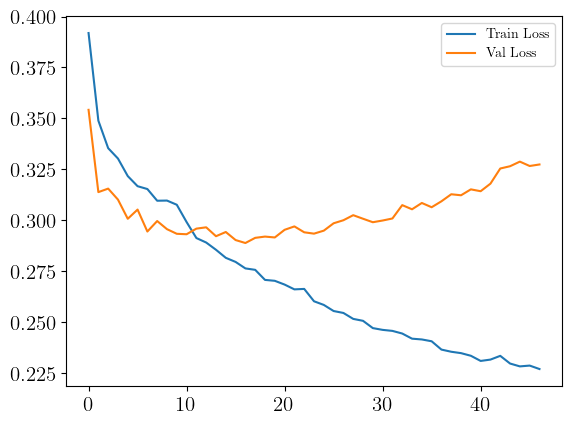

In [5]:
# Load data and train the model

if __name__ == "__main__":

    importlib.reload(settings) 

    device, device_type = get_device()
    print(f"Using device: {device_type}")
    
    model = ModifiedModel(input_dim=2048, num_classes=settings.N_CLASSES).to(device)

    trained_model, trainlosses, vallosses, timestr = train_model(X_embeddings_train, y_train, model, device, save=True)
    #trained_model_2, _, _ = train_model(X_embeddings_env, y_env, trained_model, device, save=True)


Saved loss plot in vector PDF: history/20251212-162657/loss_plot.pdf


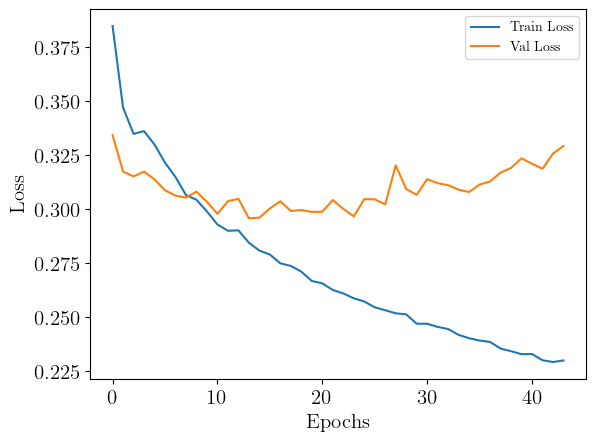

In [30]:

plt.plot(trainlosses, label='Train Loss')
plt.plot(vallosses, label='Val Loss')
plt.legend()
plt.ylabel('Loss')
plt.xlabel('Epochs')
pdf_path = f'history/20251212-162657/loss_plot.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f'Saved loss plot in vector PDF: {pdf_path}')

In [7]:
# Load model

path = "history/20251211-103901/modified_model_15.pt"  
device, _ = get_device()
synthetic_data_folder = "dataset/synthetic_data/part1"

model = torch.load(path, map_location=device, weights_only=False)

In [ ]:
# Test and evaluate the model

model.eval()
X_test_tensor = torch.tensor(X_embeddings_test, dtype=torch.float32).to(device)
with torch.no_grad():
    y_pred_test = model(X_test_tensor).cpu().numpy()
y_pred_test = postprocess_output(y_pred_test)  # If needed

# X_env_tensor = torch.tensor(X_embeddings_env, dtype=torch.float32).to(device)
# with torch.no_grad():
#     y_pred_env = model(X_env_tensor).cpu().numpy()
# y_pred_env = postprocess_output(y_pred_env)

event_metrics = EventBasedMetrics(event_label_list=settings.CLASS_NAMES, t_collar=params.PATCH_WINDOW_SECONDS)
segment_metrics = SegmentBasedMetrics(event_label_list=settings.CLASS_NAMES, time_resolution=params.PATCH_WINDOW_SECONDS)

predicted_event_list_test = predictions_to_event_list(y_pred_test)
reference_event_list_test = predictions_to_event_list(y_test)
# predicted_event_list_env = predictions_to_event_list(y_pred_env)
# reference_event_list_env = predictions_to_event_list(y_env)
print("Data processed for evaluation...")
print("Predicted event list test length:", len(predicted_event_list_test))
print("Reference event list test length:", len(reference_event_list_test))
# print("Predicted event list env length:", len(predicted_event_list_env))
# print("Reference event list env length:", len(reference_event_list_env))

event_metrics.evaluate(predicted_event_list_test, reference_event_list_test)
segment_metrics.evaluate(predicted_event_list_test, reference_event_list_test)

save_sed_metric('Event-based-dataset', event_metrics.results(), '20251212-162657')
save_sed_metric('Segment-based-dataset', segment_metrics.results(), '20251212-162657')
print_metrics(event_metrics.results(), "Event-based (Test set)")
print_metrics(segment_metrics.results(), "Segment-based (Test set)")

# event_metrics.evaluate(predicted_event_list_env, reference_event_list_env)
# segment_metrics.evaluate(predicted_event_list_env, reference_event_list_env)

# save_sed_metric('Event-based-env-dataset', event_metrics.results(), timestr)
# save_sed_metric('Segment-based-env-dataset', segment_metrics.results(), timestr)
# print_metrics(event_metrics.results(), "Event-based (Environment set)")
# print_metrics(segment_metrics.results(), "Segment-based (Environment set)")

Data processed for evaluation...
Predicted event list test length: 14547
Reference event list test length: 17013

Event-based (Test set)
  F1: 0.842 | Precision: 0.781 | Recall: 0.914
  Error Rate: 0.301
  Class-wise F1:
    No aircraft: 0.748
    Aircraft: 0.894

Segment-based (Test set)
  F1: 0.843 | Precision: 0.783 | Recall: 0.913
  Error Rate: 0.299
  Accuracy: 0.861
  Class-wise F1:
    No aircraft: 0.748
    Aircraft: 0.896


In [18]:
# Load metrics if desired

event_metric = load_sed_metric(f'history/20251212-162657/Event-based-dataset.pk1')
segment_metric = load_sed_metric(f'history/20251212-162657/Segment-based-dataset.pk1')

print_metrics(event_metrics.results_class_wise_average_metrics(), "Event-based (Env set)")
print_metrics(segment_metrics.results_class_wise_average_metrics(), "Segment-based (Env set)")



Event-based (Env set)


KeyError: 'overall'